# Exploratory Data Analysis (EDA): Music Context & Structure

**Course**: CSE425 / EEE474 / CSE715 Neural Networks Project  
**Focus**: Audio features, tag distributions, and graph topology for music understanding.

This notebook covers:
1. **Audio Feature Exploration**: Log-mel spectrograms, chromagrams, and MFCC representations.
2. **Music Tag Taxonomy**: Multi-label distribution and co-occurrence patterns.
3. **Graph Topology Analysis**: Segment similarity networks and chord progression transitions.

In [1]:
import sys
from pathlib import Path

project_root = str(Path.cwd().parent) if Path.cwd().name == 'notebooks' else str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import yaml

from src.audio_features import AudioFeatureExtractor, generate_synthetic_audio, set_seed, load_config
from src.graph_builder import build_segment_graph

config = load_config('config.yaml')
set_seed(config.get('seed', 42))
print('Config loaded successfully.')

C:\Users\User\projects\GNN-Bert-Music-Generation\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


2026-09-14 17:16:58,066 [INFO] audio_features: Random seed set to: 42


Config loaded successfully.


## 1. Feature Representation Analysis
Inspect the frequency and harmonic characteristics of music audio windows.

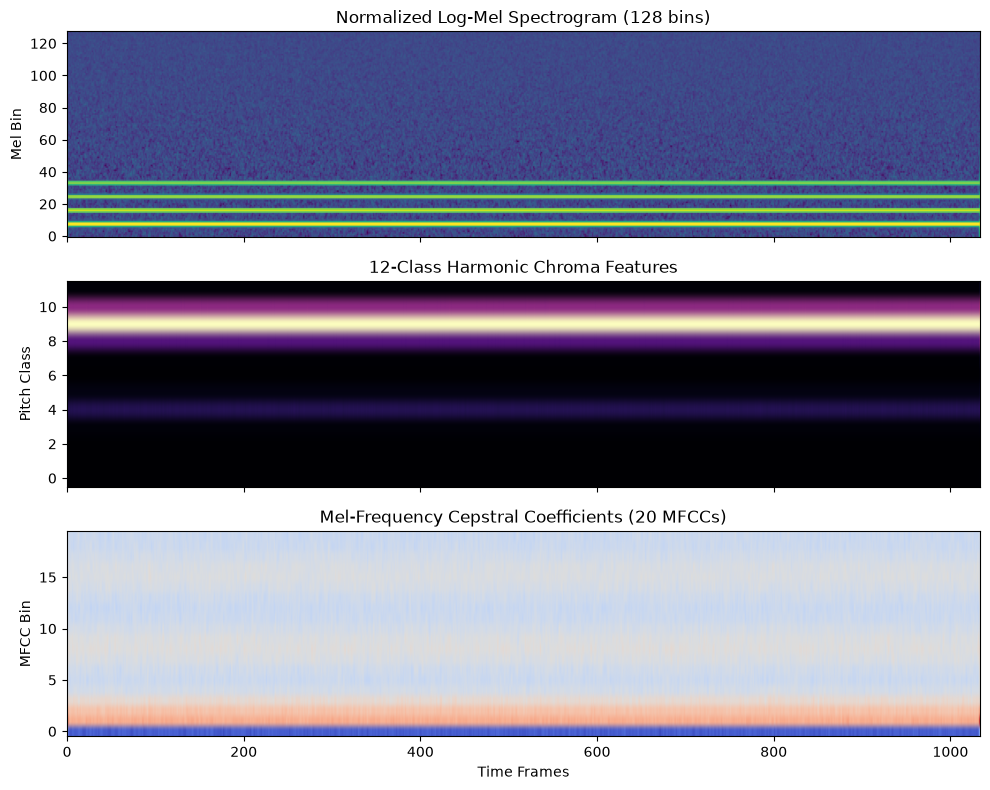

In [2]:
extractor = AudioFeatureExtractor.from_config('config.yaml')
audio = generate_synthetic_audio(duration=24.0, sample_rate=extractor.sample_rate)

track_feats = extractor.compute_track_features(audio)
mel = track_feats['log_mel']
chroma = track_feats['chroma']
mfcc = track_feats['mfcc']

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].imshow(mel, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Normalized Log-Mel Spectrogram (128 bins)')
axes[0].set_ylabel('Mel Bin')

axes[1].imshow(chroma, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('12-Class Harmonic Chroma Features')
axes[1].set_ylabel('Pitch Class')

axes[2].imshow(mfcc, aspect='auto', origin='lower', cmap='coolwarm')
axes[2].set_title('Mel-Frequency Cepstral Coefficients (20 MFCCs)')
axes[2].set_ylabel('MFCC Bin')
axes[2].set_xlabel('Time Frames')

plt.tight_layout()
plt.show()

## 2. Music Segment Graph Connectivity
Analyze edge density, degree distributions, and similarity graph topology.

In [3]:
node_features = extractor.extract_segment_features(audio)
graph = build_segment_graph(node_features, similarity_threshold=0.7, add_temporal_edges=True)

print(f'Graph Nodes (Segments): {graph.num_nodes}')
print(f'Graph Edges (Connections): {graph.num_edges}')
print('Edge Index: \n', graph.edge_index.numpy())
print('Edge Weights: \n', graph.edge_attr.numpy().flatten())

Graph Nodes (Segments): 9
Graph Edges (Connections): 81
Edge Index: 
 [[0 1 1 2 2 3 3 4 4 5 5 6 6 7 7 8 0 2 0 3 0 4 0 5 0 6 0 7 0 8 1 3 1 4 1 5
  1 6 1 7 1 8 2 4 2 5 2 6 2 7 2 8 3 5 3 6 3 7 3 8 4 6 4 7 4 8 5 7 5 8 6 8
  0 1 2 3 4 5 6 7 8]
 [1 0 2 1 3 2 4 3 5 4 6 5 7 6 8 7 2 0 3 0 4 0 5 0 6 0 7 0 8 0 3 1 4 1 5 1
  6 1 7 1 8 1 4 2 5 2 6 2 7 2 8 2 5 3 6 3 7 3 8 3 6 4 7 4 8 4 7 5 8 5 8 6
  0 1 2 3 4 5 6 7 8]]
Edge Weights: 
 [0.99948424 0.99948424 0.9997985  0.9997985  0.99980134 0.99980134
 0.99984425 0.99984425 0.99977416 0.99977416 0.99981445 0.99981445
 0.99973404 0.99973404 0.99968076 0.99968076 0.9991804  0.9991804
 0.99914396 0.99914396 0.9992882  0.9992882  0.9992422  0.9992422
 0.9992275  0.9992275  0.99934286 0.99934286 0.9995369  0.9995369
 0.99959695 0.99959695 0.99969023 0.99969023 0.9996284  0.9996284
 0.9995546  0.9995546  0.99961436 0.99961436 0.9994993  0.9994993
 0.9997007  0.9997007  0.99958557 0.99958557 0.9994457  0.9994457
 0.9995205  0.9995205  0.9994733  0.9994733  